# Otsu Thresholding (using Pore2Chip)

In [1]:
# Importing necessary libraries
from pore2chip import metrics, filter_im, coordination, generate, export
import cv2 as cv
import os
import copy
import numpy as np
from matplotlib import pyplot as plt

[09:39:47] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=560287;file://c:\Users\truo663\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=777525;file://c:\Users\truo663\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

## Method 1:
Read images externally and filter images using ```filter_im.filter```. If you already have images loaded in memory, this function will filter it using Otsu's filtering.

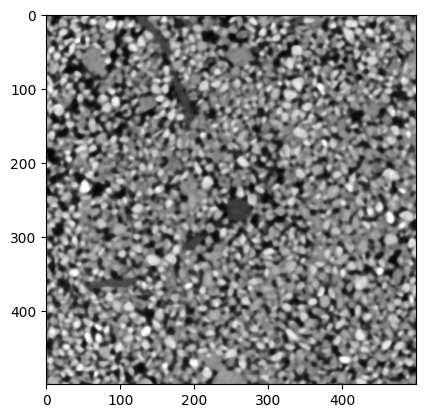

In [8]:
# Set up image path and 3D array to contain input images
image_path = r'bean_bucket_100/'

# Edit the number of desired XCT slices to threshold
num_slices = 10


image_list_3D = np.zeros((num_slices, 500, 500), dtype = np.uint8)

# Load image into each slice in 3D array
stride = 0
for i, file in enumerate(os.listdir(image_path)):
    if i == num_slices:
        break
    image = cv.imread(image_path + file, cv.IMREAD_GRAYSCALE)
    image_list_3D[stride,:,:] = copy.deepcopy(image)
    stride += 1

fig, ax = plt.subplots()
ax.imshow(image_list_3D[9,:,:], cmap='gray')

Here is where we filter the images from image data loaded in memory.

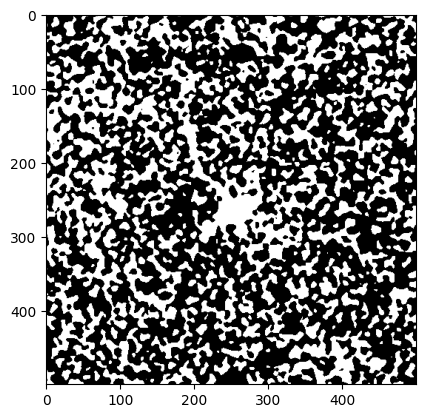

In [11]:
# Filter image and crop image down to 50 x 50, with a depth of 50
filtered_images = filter_im.filter_list(image_list_3D, invert=True)
fig, ax = plt.subplots()
ax.imshow(filtered_images[0,:,:], cmap='gray')

## Method 2:
Input image path and filter using ```filter_im.read_and_filter_list```. This will load and filter the image files in one go. All parameters after the image_path variable are option. If no depth is given, All of the images in the directory will be loaded.

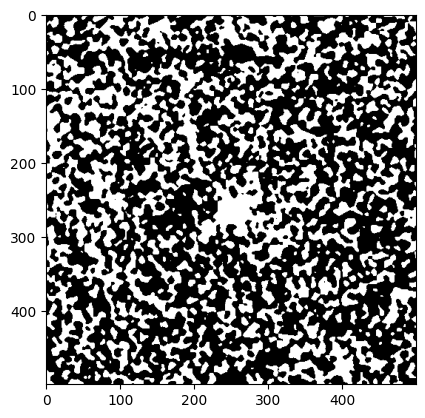

In [14]:
image_path = r'bean_bucket_100/'
# Reads and loads all images in the image_path string. This lines reads and filters a 50 x 50 x 50 3D image set
filtered_images = filter_im.read_and_filter_list(image_path, crop_depth=10, invert=True)

fig, ax = plt.subplots()
ax.imshow(filtered_images[1,:,:], cmap='gray')

# Saving Thresholded Data

In [16]:
if not os.path.exists('filtered_images'):
    os.makedirs('filtered_images')

for i, image in enumerate(filtered_images):
    cv.imwrite('filtered_images/slice' + str(i) + '.png', image)

In [7]:
plt.close('all')